In [314]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import os
import joblib

In [315]:
data = pd.read_csv('../datasets/data_compramostucoche.csv')
data.head()

,marca,modelo,version,registration,km,gear_type,fuel_type,power,price
0,Peugeot,3008,1.2 PureTech,07/2017,133864,Manual,Gasolina,130,10499
1,Peugeot,3008,1.5 Blue-HDi,04/2019,86230,Manual,Diésel,130,13699
2,Ford,Fiesta,1.0 EcoBoost,02/2020,65559,Manual,Gasolina,95,13299
3,Peugeot,2008,1.5 Blue-HDi,06/2020,94913,Automático,Diésel,131,15399
4,Audi,Q7,3.0 V6 TDI,11/2015,147531,Automático,Diésel,272,29699


In [316]:
data = data.rename(columns={
    'marca': 'make',
    'modelo': 'model',
    'km': 'kms',
})

In [317]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   make          3035 non-null   str  
 1   model         3035 non-null   str  
 2   version       3035 non-null   str  
 3   registration  3035 non-null   str  
 4   kms           3035 non-null   int64
 5   gear_type     3035 non-null   str  
 6   fuel_type     3035 non-null   str  
 7   power         3035 non-null   int64
 8   price         3035 non-null   int64
dtypes: int64(3), str(6)
memory usage: 213.5 KB


In [318]:
data.describe()

,kms,power,price
count,3035.000000,3035.000000,3035.000000
mean,79511.241516,133.068534,16553.958814
std,39277.537877,44.728234,6694.812307
min,23.000000,60.000000,6299.000000
25%,47780.500000,105.000000,11599.000000
50%,78461.000000,125.000000,15099.000000
75%,109457.500000,150.000000,19999.000000
max,159848.000000,404.000000,50899.000000


In [319]:
data.isnull().sum()

make            0
model           0
version         0
registration    0
kms             0
gear_type       0
fuel_type       0
power           0
price           0
dtype: int64

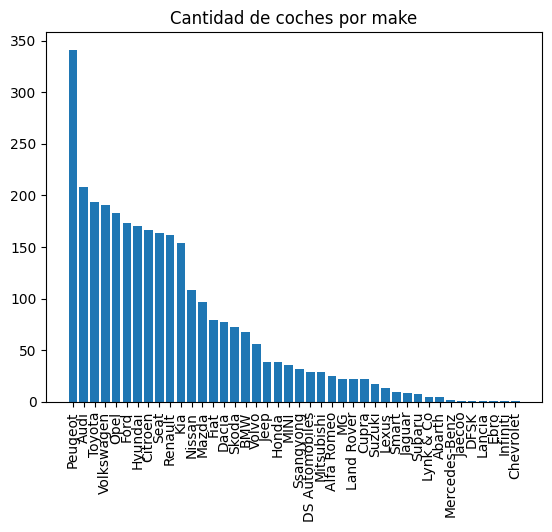

In [320]:
plt.bar(data['make'].value_counts().index, data['make'].value_counts().values)
plt.xticks(rotation=90)
plt.title('Cantidad de coches por make')
plt.show()

In [321]:
print(data['make'].value_counts())

make
Peugeot           341
Audi              208
Toyota            194
Volkswagen        191
Opel              183
Ford              173
Hyundai           170
Citroen           167
Seat              164
Renault           162
Kia               154
Nissan            108
Mazda              97
Fiat               79
Dacia              77
Skoda              73
BMW                68
Volvo              56
Jeep               39
Honda              39
MINI               36
Ssangyong          32
DS Automobiles     29
Mitsubishi         29
Alfa Romeo         25
MG                 22
Land Rover         22
Cupra              22
Suzuki             17
Lexus              13
Smart              10
Jaguar              9
Subaru              8
Lynk & Co           5
Abarth              5
Mercedes-Benz       2
Jaecoo              1
DFSK                1
Lancia              1
Ebro                1
Infiniti            1
Chevrolet           1
Name: count, dtype: int64


In [322]:
df_makes_precio_medio = data.groupby(['make'])['price'].mean().reset_index()
df_makes_precio_medio

,make,price
0,Abarth,18719.000000
1,Alfa Romeo,21095.000000
2,Audi,21980.730769
3,BMW,24453.411765
4,Chevrolet,8799.000000
5,Citroen,12385.826347
6,Cupra,27439.909091
7,DFSK,19599.000000
8,DS Automobiles,17123.137931
9,Dacia,12634.064935


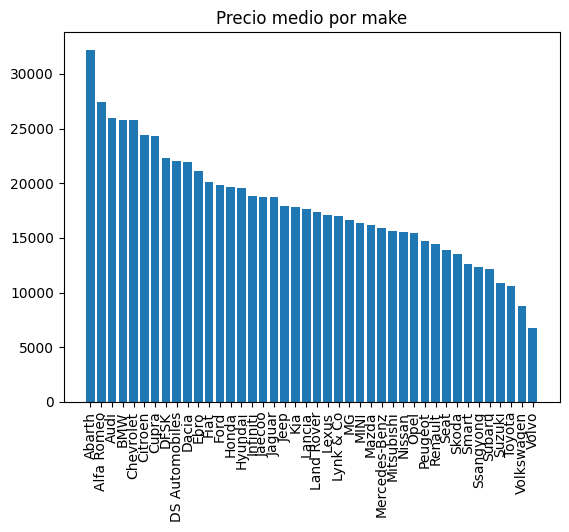

In [323]:
plt.bar(df_makes_precio_medio['make'], df_makes_precio_medio['price'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Precio medio por make')
plt.show()

In [324]:
df_makes_kms_medios = data.groupby(['make'])['kms'].mean().reset_index()

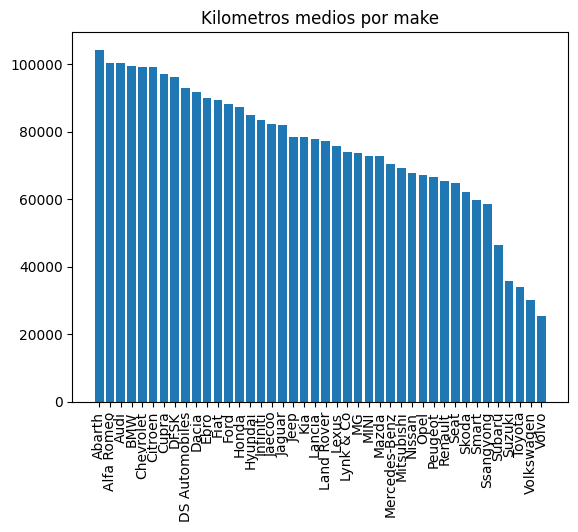

In [325]:
plt.bar(df_makes_kms_medios['make'], df_makes_kms_medios['kms'].sort_values(ascending=False))
plt.xticks(rotation=90)
plt.title('Kilometros medios por make')
plt.show()

In [326]:
data[data['make'] == 'Abarth']

,make,model,version,registration,kms,gear_type,fuel_type,power,price
1075,Abarth,595,1.4 Turbo,09/2020,90134,Manual,Gasolina,145,14999
2148,Abarth,695,1.4 Turbo,11/2022,31198,Manual,Gasolina,179,22499
2268,Abarth,500,1.4 Turbo,08/2024,22446,Manual,Gasolina,179,24999
2341,Abarth,595C,1.4,05/2019,100392,Automático,Gasolina,180,15899
2413,Abarth,595,1.4,05/2019,82228,Manual,Gasolina,160,15199


In [327]:
data['registration'] = pd.to_datetime(data['registration'], format='%m/%Y')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   make          3035 non-null   str           
 1   model         3035 non-null   str           
 2   version       3035 non-null   str           
 3   registration  3035 non-null   datetime64[us]
 4   kms           3035 non-null   int64         
 5   gear_type     3035 non-null   str           
 6   fuel_type     3035 non-null   str           
 7   power         3035 non-null   int64         
 8   price         3035 non-null   int64         
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 213.5 KB


In [328]:
df_groupby_model = data.groupby(['model', 'make']).agg({
    'kms': 'mean', 
    'power': 'mean', 
    'registration': 'mean', 
    'price': 'mean'
}).reset_index()
df_groupby_model

,model,make,kms,power,registration,price
0,01,Lynk & Co,73879.600000,261.000000,2022-09-30 19:12:00.000000,22019.000000
1,108,Peugeot,88347.846154,72.615385,2019-01-03 09:13:50.769230,8552.846154
2,2,Mazda,75191.791667,133.708333,2020-05-03 21:00:00.000000,17940.666667
3,2008,Peugeot,72841.040000,118.213333,2020-01-05 12:28:48.000000,13445.666667
4,208,Peugeot,68810.840909,94.068182,2019-11-20 05:27:16.363636,10378.545455
...,...,...,...,...,...,...
303,i40,Hyundai,130029.000000,135.000000,2014-04-01 00:00:00.000000,8999.000000
304,ix20,Hyundai,67940.000000,125.000000,2016-07-01 00:00:00.000000,11699.000000
305,ix35,Hyundai,128826.857143,117.857143,2014-09-22 06:51:25.714285,11256.142857
306,pro_cee'd,Kia,134385.000000,137.500000,2017-12-31 12:00:00.000000,11699.000000


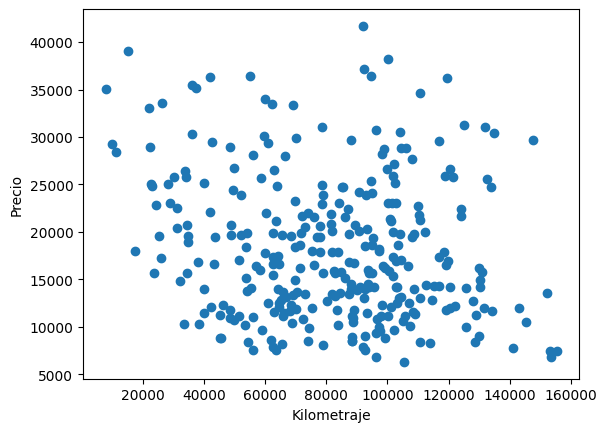

In [329]:
plt.scatter(x=df_groupby_model['kms'], y=df_groupby_model['price'])
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
plt.show()

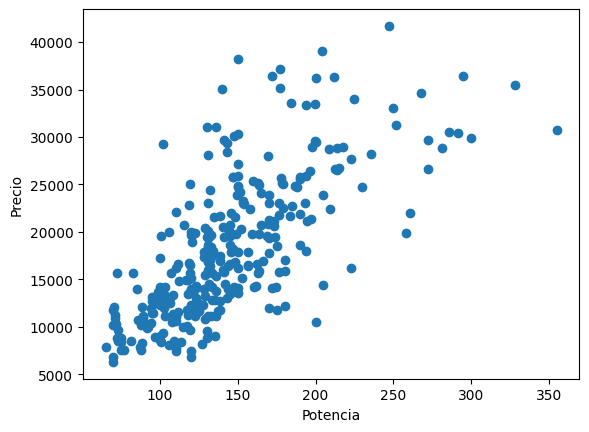

In [330]:
plt.scatter(x=df_groupby_model['power'], y=df_groupby_model['price'])
plt.xlabel('Potencia')
plt.ylabel('Precio')
plt.show()

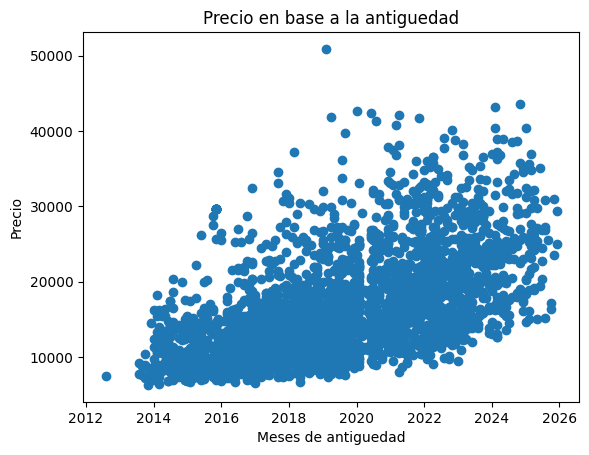

In [331]:
plt.scatter(x=data['registration'], y=data['price'])
plt.title('Precio en base a la antiguedad')
plt.xlabel('Meses de antiguedad')
plt.ylabel('Precio')
plt.show()

In [332]:
# Transformamos las columnas categoricas
data['model_unique'] = data['make'] + "_" + data['model']
data['version_unique'] = data['model_unique'] + "_" + data['version']

le = LabelEncoder()
data['make_num'] = le.fit_transform(data['make'])
data['model_num'] = le.fit_transform(data['model_unique'])
data['version_num'] = le.fit_transform(data['version_unique'])

oe = OneHotEncoder()
cols_to_encode = ['gear_type', 'fuel_type']

encoded_array = oe.fit_transform(data[cols_to_encode]).toarray() 

df_encoded = pd.DataFrame(
    encoded_array, 
    columns=oe.get_feature_names_out(cols_to_encode),
    index=data.index
)

df_final = pd.concat([data, df_encoded], axis=1)

cols_to_drop = [
    'make', 'model', 'version', 'fuel_type', 'gear_type', 
    'model_unique', 'version_unique'
]

hoy = pd.Timestamp.now()
df_final['antiguedad_meses'] = ((hoy.year - data['registration'].dt.year) * 12 + (hoy.month - data['registration'].dt.month))

# Eliminamos la columna original de fecha porque el modelo no la entiende
df_final = df_final.drop(columns=['registration'])

df_final.drop(cols_to_drop, axis=1, inplace=True)

In [333]:
df_final.head()

,kms,power,price,make_num,model_num,version_num,gear_type_Automático,gear_type_Doble embrague,gear_type_Manual,gear_type_Semi-automático,fuel_type_Diésel,fuel_type_Gasolina,fuel_type_Híbrido,antiguedad_meses
0,133864,130,10499,31,201,600,0.0,0.0,1.0,0.0,0.0,1.0,0.0,105
1,86230,130,13699,31,201,601,0.0,0.0,1.0,0.0,1.0,0.0,0.0,84
2,65559,95,13299,12,85,250,0.0,0.0,1.0,0.0,0.0,1.0,0.0,74
3,94913,131,15399,31,199,592,1.0,0.0,0.0,0.0,1.0,0.0,0.0,70
4,147531,272,29699,2,27,95,1.0,0.0,0.0,0.0,1.0,0.0,0.0,125


Text(0.5, 1.0, 'Outliers de Kilómetros')

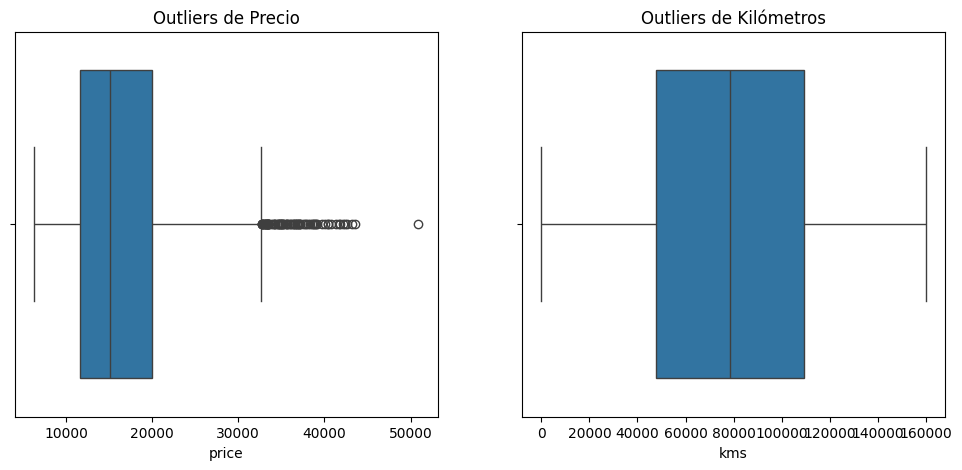

In [334]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=data['price'])
plt.title('Outliers de Precio')

# Gráfico para kms
plt.subplot(1, 2, 2)
sns.boxplot(x=data['kms'])
plt.title('Outliers de Kilómetros')

In [335]:
#  Vemos el porcentaje de outliers
print(df_final[df_final['price'] > 35000]['price'].count())
total_outliers = len(df_final[df_final['price'] > 34000])
porcentaje = (total_outliers / len(df_final)) * 100
print(f"Porcentaje de outliers en price: {porcentaje}")

47
Porcentaje de outliers en price: 1.8780889621087316


In [336]:
df_final = df_final[df_final['price'] <= 32500]

Text(0.5, 1.0, 'Outliers de Precio')

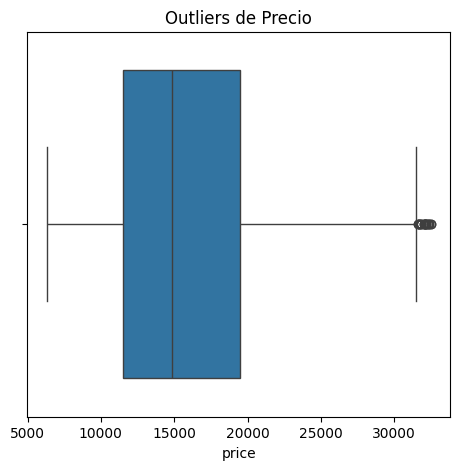

In [337]:
plt.figure(figsize=(12, 5))

# Gráfico para Precio
plt.subplot(1, 2, 1)
sns.boxplot(x=df_final['price'])
plt.title('Outliers de Precio')

In [338]:
# Exportamos el dataset
df_clean = data[data['price'] <= 32500].drop(columns=['model_unique', 'version_unique', 'make_num', 'model_num', 'version_num'])

In [339]:
# División de datos
X = df_final.drop(columns='price')
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [340]:
X.info()

<class 'pandas.DataFrame'>
Index: 2956 entries, 0 to 3034
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   kms                        2956 non-null   int64  
 1   power                      2956 non-null   int64  
 2   make_num                   2956 non-null   int64  
 3   model_num                  2956 non-null   int64  
 4   version_num                2956 non-null   int64  
 5   gear_type_Automático       2956 non-null   float64
 6   gear_type_Doble embrague   2956 non-null   float64
 7   gear_type_Manual           2956 non-null   float64
 8   gear_type_Semi-automático  2956 non-null   float64
 9   fuel_type_Diésel           2956 non-null   float64
 10  fuel_type_Gasolina         2956 non-null   float64
 11  fuel_type_Híbrido          2956 non-null   float64
 12  antiguedad_meses           2956 non-null   int32  
dtypes: float64(7), int32(1), int64(5)
memory usage: 311.8 KB


In [341]:
# Entrenamiento del modelo
# Como es calcular un precio, usaremos una regresión
model = XGBRegressor(n_estimators=450, learning_rate=0.07, max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [342]:
# Para calcular el MAE real, revertimos con expm1 de numpy
preds_log = model.predict(X_test)

mae = mean_absolute_error(y_test, preds_log)
r2 = r2_score(y_test, preds_log)

print(f"MAE: {mae}")
print(f"R2: {r2}")

MAE: 1281.85595703125
R2: 0.9055050015449524


In [343]:
# Calcular el error relativo
error_relativo = (mae / df_final['price'].mean()) * 100

print(f"Error relativo: {error_relativo}")

Error relativo: 8.001559885161798


In [344]:
# Guardar modelo
if not os.path.exists('../ai_models'):
    os.makedirs('../ai_models')

if not os.path.exists('../ai_models/compra_coches'):
    os.makedirs('../ai_models/compra_coches')

# Guardar modelo
joblib.dump(model, '../ai_models/compra_coches/modelo_compra_coches_iberia.pkl')

# Guardr lista de columnas de los datos a entrenar
joblib.dump(X_train.columns, '../ai_models/compra_coches/columnas_modelo_compra_coches_iberia.pkl')

['../ai_models/compra_coches/columnas_modelo_compra_coches_iberia.pkl']

In [345]:
def predecir_coche(power, make_num, model_num, version_num, kms, meses, gear, fuel):
    # Creamos la fila base con ceros
    nuevo_coche = pd.DataFrame(0, index=[0], columns=X_train.columns)
    
    # Rellenamos valores numéricos y ordinales
    nuevo_coche['kms'] = kms
    nuevo_coche['antiguedad_meses'] = meses
    nuevo_coche['power'] = power
    nuevo_coche['make_num'] = make_num
    nuevo_coche['model_num'] = model_num
    nuevo_coche['version_num'] = version_num
    
    # Activamos el Dummy correspondiente basándonos en el texto
    # Ejemplo: si gear='Manual', activa 'gear_type_Manual'
    col_gear = f'gear_type_{gear}'
    col_fuel = f'fuel_type_{fuel}'
    
    if col_gear in nuevo_coche.columns:
        nuevo_coche[col_gear] = 1.0
    if col_fuel in nuevo_coche.columns:
        nuevo_coche[col_fuel] = 1.0
    
    prediccion = model.predict(nuevo_coche)
    
    return prediccion[0]


In [346]:
# Ejemplo de uso mucho más natural:
precio_estimado = predecir_coche(90, 5, 12, 104, 14469, 48, 'Manual', 'Diésel')
print(f"El valor estimado para este coche es de: {precio_estimado:.2f} €")

El valor estimado para este coche es de: 17487.78 €


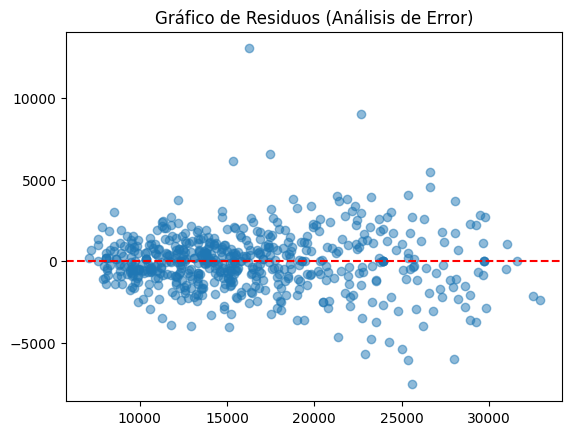

In [347]:
error = y_test - model.predict(X_test)
plt.scatter(model.predict(X_test), error, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Gráfico de Residuos (Análisis de Error)')
plt.show()

In [348]:
df_clean['is_prediction'] = False
df_clean['rep_id'] = 1

df_clean.to_csv('../datasets/coches_clean.csv', index=False)

In [349]:
fuel_bbdd = {
    'id': range(1, len(df_clean['fuel_type'].unique()) + 1),
    'nombre': sorted(df_clean['fuel_type'].unique())
}
pd.DataFrame(fuel_bbdd).to_csv('../datasets/seed_fuel_types.csv', index=False)

In [350]:
fuel_bbdd = {
    'id': range(1, len(df_clean['gear_type'].unique()) + 1),
    'nombre': sorted(df_clean['gear_type'].unique())
}
pd.DataFrame(fuel_bbdd).to_csv('../datasets/seed_gear_types.csv', index=False)

In [351]:
df_marcas_seed = pd.read_csv('../datasets/seed_marcas.csv')
df_modelos_seed = pd.read_csv('../datasets/seed_modelos.csv')
df_datos_scraping = pd.read_csv('../datasets/data_compramostucoche.csv')

In [352]:
modelos_bbdd = []
mapa_marca_modelo_a_id = {}

dict_nombres_marcas = df_marcas_seed.set_index('id')['nombre'].to_dict()

for _, row in df_modelos_seed.iterrows():
    m_id = row['id_marca']
    nombre_marca = dict_nombres_marcas.get(m_id, "Desconocida").lower().strip()
    nombre_modelo = str(row['nombre']).lower().strip()
    
    # Guardamos el ID original del CSV de modelos
    mapa_marca_modelo_a_id[(nombre_marca, nombre_modelo)] = row['id']
    
    modelos_bbdd.append({
        "id": row['id'],
        "nombre": row['nombre'],
        "id_marca": m_id
    })

versiones_bbdd = []
versiones_vistas = set()
contador_versiones = 1

for _, coche in df_datos_scraping.iterrows():
    marca_coche = str(coche['marca']).lower().strip()
    modelo_coche = str(coche['modelo']).lower().strip()
    nombre_version = str(coche['version']).strip()
    
    llave_busqueda = (marca_coche, modelo_coche)
    id_modelo_relacionado = mapa_marca_modelo_a_id.get(llave_busqueda)

    clave_version = (id_modelo_relacionado, nombre_version.lower())
    
    if id_modelo_relacionado and clave_version not in versiones_vistas:
        versiones_bbdd.append({
            "id": contador_versiones,
            "nombre": nombre_version,
            "id_modelo": int(id_modelo_relacionado)
        })
        versiones_vistas.add(clave_version)
        contador_versiones += 1

In [353]:
df_versiones_final = pd.DataFrame(versiones_bbdd)
df_versiones_final.to_csv('../datasets/seed_versiones.csv', index=False)